In [1]:
from pathlib import Path
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [2]:
DATA_ROOT = Path("dataset/humanfaces")
IMG_SIZE = 224
BATCH_SIZE = 32

base_dataset = datasets.ImageFolder(root=str(DATA_ROOT))
targets = np.array(base_dataset.targets)
indices = np.arange(len(base_dataset))

print("Classes:", base_dataset.class_to_idx)
print("Total images:", len(base_dataset))
print("Class counts:", {name: int((targets == idx).sum()) for name, idx in base_dataset.class_to_idx.items()})

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, random_state=SEED, stratify=targets
)
temp_targets = targets[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=SEED, stratify=temp_targets
)

print("Split sizes:", len(train_idx), len(val_idx), len(test_idx))

Classes: {'ai': 0, 'real': 1}
Total images: 9630
Class counts: {'ai': 4630, 'real': 5000}
Split sizes: 6741 1444 1445


In [3]:
class DeepfakeDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.10), ratio=(0.3, 3.3)),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_samples = [base_dataset.samples[i] for i in train_idx]
val_samples = [base_dataset.samples[i] for i in val_idx]
test_samples = [base_dataset.samples[i] for i in test_idx]

train_dataset = DeepfakeDataset(train_samples, transform=train_transform)
val_dataset = DeepfakeDataset(val_samples, transform=eval_transform)
test_dataset = DeepfakeDataset(test_samples, transform=eval_transform)

In [4]:
pin_memory = device.type == "cuda"

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])


In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        residual = self.shortcut(x)
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = self.bn2(self.conv2(x))
        return torch.relu(x + residual)

class DeepFakeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.block1 = ResidualBlock(32, 64, stride=2, dropout=0.05)
        self.block2 = ResidualBlock(64, 128, stride=2, dropout=0.10)
        self.block3 = ResidualBlock(128, 256, stride=2, dropout=0.15)
        self.block4 = ResidualBlock(256, 256, stride=1, dropout=0.15)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.50),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool(x)
        return self.head(x)

model = DeepFakeCNN().to(device)
model

DeepFakeCNN(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (block1): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (dropout): Dropout2d(p=0.05, inplace=False)
    (shortcut): Sequential(
      (0): Conv2d(32, 64, kernel_size=(1, 1

In [6]:
train_counts = np.bincount(targets[train_idx], minlength=2)
class_weights = torch.tensor(len(train_idx) / (2.0 * train_counts), dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_items = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_items += batch_size

    return total_loss / total_items, total_correct / total_items

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_items = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_items += batch_size

    return total_loss / total_items, total_correct / total_items

C:\Users\Muhammad Hassan\AppData\Local\Temp\ipykernel_4980\1001729767.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")


In [7]:
epochs = 5
patience = 5
best_val_loss = float("inf")
best_state = None
patience_left = patience
history = []

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)
    scheduler.step(val_loss)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        patience_left = patience
    else:
        patience_left -= 1
        if patience_left == 0:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

best_model_path = "deepfake_cnn_best.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": base_dataset.class_to_idx,
    "img_size": IMG_SIZE,
}, best_model_path)
print("Saved:", best_model_path)

C:\Users\Muhammad Hassan\AppData\Local\Temp\ipykernel_4980\1001729767.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):


Epoch 01 | train loss 0.3288 acc 0.8905 | val loss 0.2567 acc 0.9238
Epoch 02 | train loss 0.2401 acc 0.9420 | val loss 0.2594 acc 0.9238
Epoch 03 | train loss 0.2099 acc 0.9599 | val loss 0.2129 acc 0.9488
Epoch 04 | train loss 0.1877 acc 0.9712 | val loss 0.2583 acc 0.9314
Epoch 05 | train loss 0.1841 acc 0.9721 | val loss 0.1781 acc 0.9702
Saved: deepfake_cnn_best.pth


[[694   1]
 [ 42 708]]
              precision    recall  f1-score   support

          ai       0.94      1.00      0.97       695
        real       1.00      0.94      0.97       750

    accuracy                           0.97      1445
   macro avg       0.97      0.97      0.97      1445
weighted avg       0.97      0.97      0.97      1445

Test ROC-AUC: 0.9993573141486811


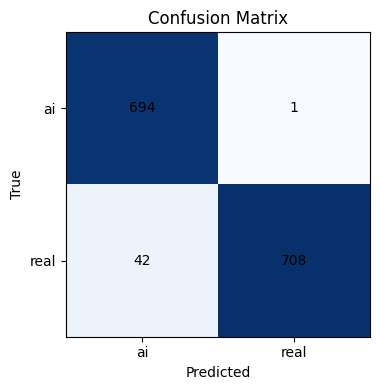

In [8]:
@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)

        y_true.extend(labels.numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())
        y_prob.extend(probs.cpu().numpy().tolist())

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

y_true, y_pred, y_prob = collect_predictions(model, test_loader)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=list(base_dataset.class_to_idx.keys())))
print("Test ROC-AUC:", roc_auc_score(y_true, y_prob))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks([0, 1], list(base_dataset.class_to_idx.keys()))
plt.yticks([0, 1], list(base_dataset.class_to_idx.keys()))
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

In [9]:
def predict_image(path):
    image = Image.open(path).convert("RGB")
    tensor = eval_transform(image).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        prob_fake = torch.softmax(logits, dim=1)[0, 1].item()
    label = "FAKE" if prob_fake >= 0.5 else "REAL"
    return label, prob_fake

sample_path = test_samples[0][0]
label, confidence = predict_image(sample_path)
print("Prediction:", label)
print("Fake probability:", confidence)

Prediction: REAL
Fake probability: 0.022067321464419365


## Upload and Check

Use the widget below to upload a face image and get an instant REAL/FAKE prediction from the trained model.

In [10]:
import io

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import clear_output, display
from PIL import Image as PILImage

trained_model = globals().get("model")

upload_widget = widgets.FileUpload(accept="image/*", multiple=False)
check_button = widgets.Button(description="Check image", button_style="primary")
output_widget = widgets.Output()


def _extract_uploaded_image(upload_value):
    if not upload_value:
        return None, None

    if isinstance(upload_value, dict):
        uploaded_item = next(iter(upload_value.values()))
    else:
        uploaded_item = upload_value[0]

    image_bytes = uploaded_item["content"]
    image_name = uploaded_item.get("name", "uploaded_image")
    return PILImage.open(io.BytesIO(image_bytes)).convert("RGB"), image_name


def _check_uploaded_image(_button):
    with output_widget:
        clear_output()
        image, image_name = _extract_uploaded_image(upload_widget.value)

        if image is None:
            print("Upload an image first.")
            return

        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title(image_name)
        plt.show()

        if trained_model is None:
            print("Run the training cells first so a loaded model is available.")
            return

        tensor = eval_transform(image).unsqueeze(0).to(device)
        trained_model.eval()
        with torch.no_grad():
            logits = trained_model(tensor)
            prob_fake = torch.softmax(logits, dim=1)[0, 1].item()

        label = "FAKE" if prob_fake >= 0.5 else "REAL"
        print(f"Prediction: {label}")
        print(f"Fake probability: {prob_fake:.4f}")


check_button.on_click(_check_uploaded_image)
display(widgets.VBox([
    widgets.HTML("<h3>Upload an image and check it</h3>"),
    upload_widget,
    check_button,
    output_widget,
]))